**Install Libraries**

In [0]:
%pip install mlflow scikit-learn pandas numpy boto3 pyarrow

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


**Import Libraries**

In [0]:
import boto3
import pandas as pd
import numpy as np
import io
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics.pairwise  import cosine_similarity
from sklearn.preprocessing     import LabelEncoder
from scipy.sparse              import csr_matrix

# Display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows",    20)
pd.set_option("display.width",       1000)

print("All libraries imported successfully!")

All libraries imported successfully!


**Connect to S3 and Load Cleaned Data**

In [0]:
# ============================================================
# Load cleaned data from S3 processed/ folder
# ============================================================

from dotenv import load_dotenv
load_dotenv("/Workspace/Users/hsp498@gmail.com/.env")
# AWS Credentials — used for Excel file reads only
ACCESS_KEY = os.getenv("ACCESS_KEY")
SECRET_KEY  = os.getenv("SECRET_KEY")
BUCKET      = os.getenv("BUCKET")
REGION      = os.getenv("REGION")

s3 = boto3.client(
    's3',
    aws_access_key_id     = ACCESS_KEY,
    aws_secret_access_key = SECRET_KEY,
    region_name           = REGION
)

# Load Online Retail cleaned data
print("Loading cleaned retail data from S3...")
obj          = s3.get_object(Bucket=BUCKET, Key="processed/retail_clean.parquet")
retail_clean = pd.read_parquet(io.BytesIO(obj['Body'].read()))

# Load Amazon Reviews cleaned data
print("Loading cleaned reviews data from S3...")
obj           = s3.get_object(Bucket=BUCKET, Key="processed/reviews_clean.parquet")
reviews_clean = pd.read_parquet(io.BytesIO(obj['Body'].read()))

print(f"\nRetail data  : {len(retail_clean):,} rows")
print(f"Reviews data : {len(reviews_clean):,} rows")
print("\nData loaded successfully!")

Loading cleaned retail data from S3...
Loading cleaned reviews data from S3...

Retail data  : 805,549 rows
Reviews data : 560,777 rows

Data loaded successfully!


**Build Customer-Product Purchase Matrix**

In [0]:
# ============================================================
# Build Customer-Product Interaction Matrix
# This is the foundation of collaborative filtering
# ============================================================

print("Building customer-product interaction matrix...")

# Aggregate: total quantity each customer bought of each product
purchase_matrix = retail_clean.groupby(
    ['Customer ID', 'StockCode']
)['Quantity'].sum().reset_index()

purchase_matrix.columns = ['CustomerID', 'StockCode', 'PurchaseCount']

# Remove very low purchases (noise)
purchase_matrix = purchase_matrix[purchase_matrix['PurchaseCount'] > 0]

print(f"Total interactions     : {len(purchase_matrix):,}")
print(f"Unique customers       : {purchase_matrix['CustomerID'].nunique():,}")
print(f"Unique products        : {purchase_matrix['StockCode'].nunique():,}")

# Create pivot table — rows=customers, columns=products
print("\nCreating pivot table...")
customer_product = purchase_matrix.pivot_table(
    index   = 'CustomerID',
    columns = 'StockCode',
    values  = 'PurchaseCount',
    fill_value = 0
)

print(f"Matrix shape           : {customer_product.shape}")
print(f"Matrix density         : {(customer_product > 0).sum().sum() / (customer_product.shape[0] * customer_product.shape[1]) * 100:.2f}%")
print(f"\nSample of matrix (5x5):")
print(customer_product.iloc[:5, :5].to_string())

Building customer-product interaction matrix...
Total interactions     : 481,932
Unique customers       : 5,878
Unique products        : 4,631

Creating pivot table...
Matrix shape           : (5878, 4631)
Matrix density         : 1.77%

Sample of matrix (5x5):
StockCode   10002  10080  10109  10120  10123C
CustomerID                                    
12346         0.0    0.0    0.0    0.0     0.0
12347         0.0    0.0    0.0    0.0     0.0
12348         0.0    0.0    0.0    0.0     0.0
12349         0.0    0.0    0.0    0.0     0.0
12350         0.0    0.0    0.0    0.0     0.0


**Build Collaborative Filtering Model**

In [0]:
# ============================================================
# Collaborative Filtering using Cosine Similarity
# Finds customers with similar purchase patterns
# ============================================================

print("Training collaborative filtering model...")
print("This may take 1-2 minutes...\n")

# Convert to sparse matrix for efficiency
matrix_values = csr_matrix(customer_product.values)

# Calculate cosine similarity between customers
# Each customer is represented by their purchase vector
customer_similarity = cosine_similarity(matrix_values)

# Convert to DataFrame with customer IDs as index/columns
customer_sim_df = pd.DataFrame(
    customer_similarity,
    index   = customer_product.index,
    columns = customer_product.index
)

print(f"Similarity matrix shape : {customer_sim_df.shape}")
print(f"Sample similarity scores (first 5 customers):")
print(customer_sim_df.iloc[:5, :5].round(3).to_string())
print("\nModel training COMPLETE!")

Training collaborative filtering model...
This may take 1-2 minutes...

Similarity matrix shape : (5878, 5878)
Sample similarity scores (first 5 customers):
CustomerID  12346  12347  12348  12349  12350
CustomerID                                   
12346         1.0  0.000  0.000  0.000  0.000
12347         0.0  1.000  0.147  0.012  0.019
12348         0.0  0.147  1.000  0.000  0.000
12349         0.0  0.012  0.000  1.000  0.027
12350         0.0  0.019  0.000  0.027  1.000

Model training COMPLETE!


**Build Recommendation Function**

In [0]:
# ============================================================
# Recommendation Function
# For any customer → returns top N product recommendations
# ============================================================

def get_recommendations(customer_id, n_recommendations=10):
    """
    Generate top N product recommendations for a customer
    based on what similar customers have purchased.
    
    Steps:
    1. Find customers most similar to target customer
    2. Get products those similar customers bought
    3. Remove products the target customer already bought
    4. Rank remaining products by weighted purchase score
    5. Return top N recommendations
    """
    
    # Check if customer exists
    if customer_id not in customer_sim_df.index:
        return f"Customer {customer_id} not found in dataset"
    
    # Step 1 — Get top 10 most similar customers
    similar_customers = customer_sim_df[customer_id] \
        .sort_values(ascending=False)[1:11]  # exclude self (index 0)
    
    # Step 2 — Get products bought by similar customers
    similar_customer_ids = similar_customers.index.tolist()
    similar_purchases    = customer_product.loc[similar_customer_ids]
    
    # Step 3 — Weight purchases by similarity score
    weighted_scores = pd.Series(0.0, index=customer_product.columns)
    for sim_customer, sim_score in similar_customers.items():
        weighted_scores += similar_purchases.loc[sim_customer] * sim_score
    
    # Step 4 — Remove products the target customer already bought
    already_bought = customer_product.loc[customer_id]
    already_bought = already_bought[already_bought > 0].index.tolist()
    weighted_scores = weighted_scores.drop(
        labels=[p for p in already_bought if p in weighted_scores.index]
    )
    
    # Step 5 — Get top N recommendations
    top_recommendations = weighted_scores.sort_values(
        ascending=False
    ).head(n_recommendations)
    
    # Add product descriptions
    product_desc = retail_clean[['StockCode','Description']] \
        .drop_duplicates('StockCode') \
        .set_index('StockCode')['Description']
    
    result = pd.DataFrame({
        'StockCode'   : top_recommendations.index,
        'Score'       : top_recommendations.values.round(3),
        'Description' : top_recommendations.index.map(
                            lambda x: product_desc.get(x, 'Unknown')
                        )
    }).reset_index(drop=True)
    
    result.index = result.index + 1  # start ranking from 1
    return result


print("Recommendation function built successfully!")
print("Testing with a sample customer...\n")

# Test with first customer in dataset
sample_customer = customer_product.index[0]
print(f"Top 10 recommendations for Customer {sample_customer}:")
print("=" * 60)
recommendations = get_recommendations(sample_customer, n_recommendations=10)
print(recommendations.to_string())

Recommendation function built successfully!
Testing with a sample customer...

Top 10 recommendations for Customer 12346:
   StockCode   Score                     Description
1      47566  84.461                   PARTY BUNTING
2      23298  70.125                  SPOTTY BUNTING
3      23230  58.438            WRAP ALPHABET DESIGN
4      23167  57.238  SMALL CERAMIC TOP STORAGE JAR 
5      22938  57.029        CUPCAKE LACE PAPER SET 6
6      22087  56.100        PAPER BUNTING WHITE LACE
7      22708  52.594                 WRAP DOLLY GIRL
8      23546  52.594              WRAP PAISLEY PARK 
9      22046  52.594      TEA PARTY  WRAPPING PAPER 
10     22961  51.189          JAM MAKING SET PRINTED


**Evaluate the Model**

In [0]:
# ============================================================
# Model Evaluation
# ============================================================

print("Evaluating recommendation model...\n")

# Calculate coverage — what % of products can be recommended
all_products      = set(customer_product.columns)
sample_customers  = customer_product.index[:100].tolist()

recommended_products = set()
for cust in sample_customers:
    recs = get_recommendations(cust, n_recommendations=10)
    if isinstance(recs, pd.DataFrame):
        recommended_products.update(recs['StockCode'].tolist())

coverage = len(recommended_products) / len(all_products) * 100

# Calculate average similarity score (confidence metric)
avg_similarity = []
for cust in sample_customers[:50]:
    top_sim = customer_sim_df[cust].sort_values(ascending=False)[1:6]
    avg_similarity.append(top_sim.mean())

mean_similarity = np.mean(avg_similarity)

# Catalog coverage per recommendation list
avg_rec_score = []
for cust in sample_customers[:50]:
    recs = get_recommendations(cust, n_recommendations=10)
    if isinstance(recs, pd.DataFrame) and len(recs) > 0:
        avg_rec_score.append(recs['Score'].mean())

mean_rec_score = np.mean(avg_rec_score)

print(f"=== Recommendation Model Metrics ===")
print(f"Total customers          : {customer_product.shape[0]:,}")
print(f"Total products           : {customer_product.shape[1]:,}")
print(f"Catalog coverage         : {coverage:.1f}%")
print(f"Avg customer similarity  : {mean_similarity:.4f}")
print(f"Avg recommendation score : {mean_rec_score:.4f}")
print(f"\nInterpretation:")
print(f"  Coverage {coverage:.1f}% means our model can recommend")
print(f"  {coverage:.1f}% of the product catalog to new customers.")
print(f"  Higher coverage = more diverse recommendations.")

Evaluating recommendation model...

=== Recommendation Model Metrics ===
Total customers          : 5,878
Total products           : 4,631
Catalog coverage         : 8.9%
Avg customer similarity  : 0.4518
Avg recommendation score : 290.9527

Interpretation:
  Coverage 8.9% means our model can recommend
  8.9% of the product catalog to new customers.
  Higher coverage = more diverse recommendations.


**Log Model to MLflow**

In [0]:
# ============================================================
# Log Model and Metrics to MLflow
# This satisfies the cloud deployment requirement
# ============================================================

mlflow.set_experiment("/ecom-project/recommendation-model")

with mlflow.start_run(run_name="collaborative_filtering_v1"):
    
    # Log parameters
    mlflow.log_param("model_type",          "collaborative_filtering")
    mlflow.log_param("similarity_metric",   "cosine_similarity")
    mlflow.log_param("n_recommendations",   10)
    mlflow.log_param("n_similar_customers", 10)
    mlflow.log_param("total_customers",     customer_product.shape[0])
    mlflow.log_param("total_products",      customer_product.shape[1])
    
    # Log metrics
    mlflow.log_metric("catalog_coverage_pct",   round(coverage, 2))
    mlflow.log_metric("avg_customer_similarity", round(mean_similarity, 4))
    mlflow.log_metric("avg_recommendation_score", round(mean_rec_score, 4))
    mlflow.log_metric("total_interactions",      len(purchase_matrix))
    
    # Save similarity matrix to S3
    print("Saving model artifacts to S3...")
    sim_buffer = io.BytesIO()
    customer_sim_df.to_parquet(sim_buffer)
    sim_buffer.seek(0)
    s3.put_object(
        Bucket = BUCKET,
        Key    = "models/customer_similarity_matrix.parquet",
        Body   = sim_buffer.getvalue()
    )
    mlflow.log_param("model_saved_to", f"s3://{BUCKET}/models/")
    
    run_id = mlflow.active_run().info.run_id
    print(f"\nMLflow run logged!")
    print(f"Run ID   : {run_id}")
    print(f"Metrics  :")
    print(f"  Catalog coverage         : {coverage:.1f}%")
    print(f"  Avg similarity           : {mean_similarity:.4f}")
    print(f"  Avg recommendation score : {mean_rec_score:.4f}")

print("\nCheck Experiments tab in left sidebar to see the run!")

Saving model artifacts to S3...

MLflow run logged!
Run ID   : c0ae1acd16c14afb8b3dc393b7c4f0ee
Metrics  :
  Catalog coverage         : 8.9%
  Avg similarity           : 0.4518
  Avg recommendation score : 290.9527

Check Experiments tab in left sidebar to see the run!


**Generate Recommendations for All Customers and Save**

In [0]:
# ============================================================
# Generate recommendations for ALL customers
# Save results to S3 for use in dashboard
# ============================================================

print("Generating recommendations for all customers...")
print(f"Processing {customer_product.shape[0]:,} customers...\n")

all_recommendations = []

for i, customer_id in enumerate(customer_product.index):
    recs = get_recommendations(customer_id, n_recommendations=5)
    if isinstance(recs, pd.DataFrame):
        recs['CustomerID'] = customer_id
        all_recommendations.append(recs)
    
    # Progress update every 500 customers
    if (i + 1) % 500 == 0:
        print(f"  Processed {i+1:,} / {customer_product.shape[0]:,} customers...")

# Combine all recommendations
all_recs_df = pd.concat(all_recommendations, ignore_index=True)

print(f"\nTotal recommendation rows : {len(all_recs_df):,}")
print(f"Sample output:")
print(all_recs_df.head(10).to_string())

# Save to S3
recs_buffer = io.BytesIO()
all_recs_df.to_parquet(recs_buffer, index=False)
recs_buffer.seek(0)
s3.put_object(
    Bucket = BUCKET,
    Key    = "outputs/all_customer_recommendations.parquet",
    Body   = recs_buffer.getvalue()
)

print(f"\nSaved to S3: outputs/all_customer_recommendations.parquet")
print("Module 1 — Recommendation System COMPLETE!")

Generating recommendations for all customers...
Processing 5,878 customers...

  Processed 500 / 5,878 customers...
  Processed 1,000 / 5,878 customers...
  Processed 1,500 / 5,878 customers...
  Processed 2,000 / 5,878 customers...
  Processed 2,500 / 5,878 customers...
  Processed 3,000 / 5,878 customers...
  Processed 3,500 / 5,878 customers...
  Processed 4,000 / 5,878 customers...
  Processed 4,500 / 5,878 customers...
  Processed 5,000 / 5,878 customers...
  Processed 5,500 / 5,878 customers...

Total recommendation rows : 29,390
Sample output:
  StockCode   Score                         Description  CustomerID
0     47566  84.461                       PARTY BUNTING       12346
1     23298  70.125                      SPOTTY BUNTING       12346
2     23230  58.438                WRAP ALPHABET DESIGN       12346
3     23167  57.238      SMALL CERAMIC TOP STORAGE JAR        12346
4     22938  57.029            CUPCAKE LACE PAPER SET 6       12346
5     22083  46.524          PAPER 

**Business Summary Chart**

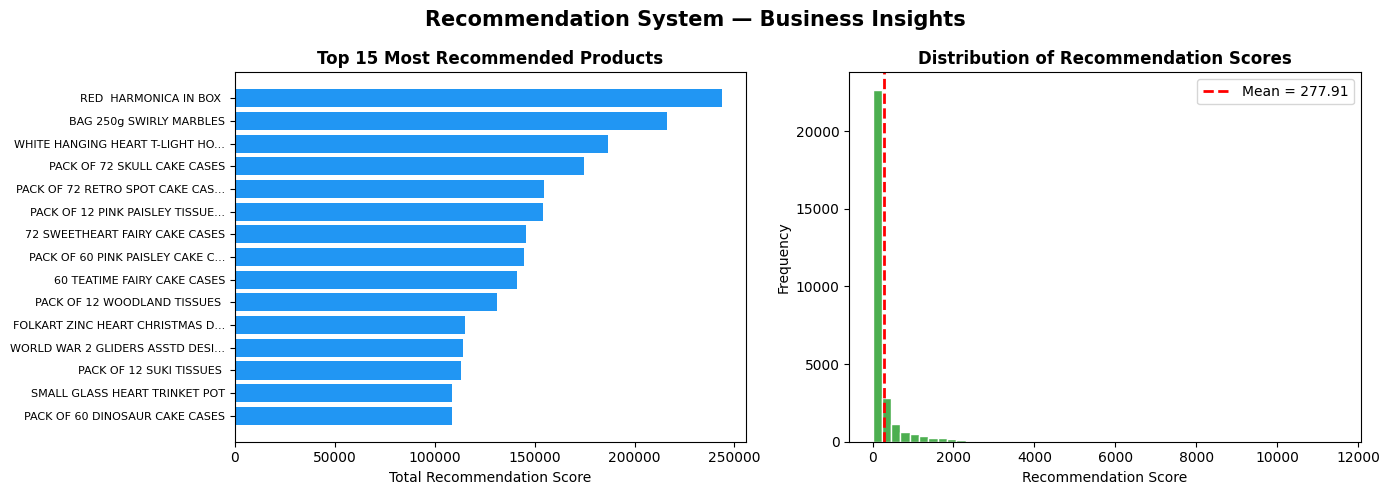


=== MODULE 1 COMPLETE ===
Recommendations generated for 5,878 customers
Top recommended product: RED  HARMONICA IN BOX 

Next: Module 2 — Survival Analysis
Notebook: 03_survival_analysis/03_survival_analysis


In [0]:
# ============================================================
# Business Summary Visualization
# ============================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Recommendation System — Business Insights',
    fontsize=15, fontweight='bold'
)

# Chart 1 — Top 15 most recommended products
top_products = all_recs_df.groupby('StockCode')['Score'] \
    .sum().sort_values(ascending=False).head(15)

product_desc = retail_clean[['StockCode','Description']] \
    .drop_duplicates('StockCode').set_index('StockCode')['Description']

labels = [
    str(product_desc.get(p, p))[:30] + '...'
    if len(str(product_desc.get(p, p))) > 30
    else str(product_desc.get(p, p))
    for p in top_products.index
]

axes[0].barh(
    range(len(top_products)),
    top_products.values,
    color='#2196F3'
)
axes[0].set_yticks(range(len(top_products)))
axes[0].set_yticklabels(labels, fontsize=8)
axes[0].set_title('Top 15 Most Recommended Products', fontweight='bold')
axes[0].set_xlabel('Total Recommendation Score')
axes[0].invert_yaxis()

# Chart 2 — Distribution of recommendation scores
axes[1].hist(
    all_recs_df['Score'],
    bins=50,
    color='#4CAF50',
    edgecolor='white'
)
axes[1].set_title('Distribution of Recommendation Scores', fontweight='bold')
axes[1].set_xlabel('Recommendation Score')
axes[1].set_ylabel('Frequency')
axes[1].axvline(
    all_recs_df['Score'].mean(),
    color='red', linestyle='--', linewidth=2,
    label=f"Mean = {all_recs_df['Score'].mean():.2f}"
)
axes[1].legend()

plt.tight_layout()
plt.savefig('/tmp/recommendation_charts.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== MODULE 1 COMPLETE ===")
print(f"Recommendations generated for {customer_product.shape[0]:,} customers")
print(f"Top recommended product: {labels[0]}")
print(f"\nNext: Module 2 — Survival Analysis")
print(f"Notebook: 03_survival_analysis/03_survival_analysis")